In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv"
df = pd.read_csv(url)

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [4]:
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv"

df = pd.read_csv(url)

df.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [5]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(161, 14)


In [6]:
print("Columns:")
print(df.columns)

Columns:
Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='str')


In [7]:
print(df.dtypes)

Product_id        int64
Price             int64
Sale              int64
weight          float64
resoloution     float64
ppi               int64
cpu core          int64
cpu freq        float64
internal mem    float64
ram             float64
RearCam         float64
Front_Cam       float64
battery           int64
thickness       float64
dtype: object


In [8]:
print(df.isnull().sum())

Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64


In [9]:
df.describe()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000
mean,675.559006,2215.596273,621.465839,170.426087,5.209938,335.055901,4.857143,1.502832,24.501714,2.204994,10.378261,4.503106,2842.111801,8.921739
std,410.851583,768.187171,1546.618517,92.888612,1.509953,134.826659,2.444016,0.599783,28.804773,1.609831,6.181585,4.342053,1366.990838,2.192564
min,10.000000,614.000000,10.000000,66.000000,1.400000,121.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,800.000000,5.100000
25%,237.000000,1734.000000,37.000000,134.100000,4.800000,233.000000,4.000000,1.200000,8.000000,1.000000,5.000000,0.000000,2040.000000,7.600000
50%,774.000000,2258.000000,106.000000,153.000000,5.150000,294.000000,4.000000,1.400000,16.000000,2.000000,12.000000,5.000000,2800.000000,8.400000
75%,1026.000000,2744.000000,382.000000,170.000000,5.500000,428.000000,8.000000,1.875000,32.000000,3.000000,16.000000,8.000000,3240.000000,9.800000
max,1339.000000,4361.000000,9807.000000,753.000000,12.200000,806.000000,8.000000,2.700000,128.000000,6.000000,23.000000,20.000000,9500.000000,18.500000


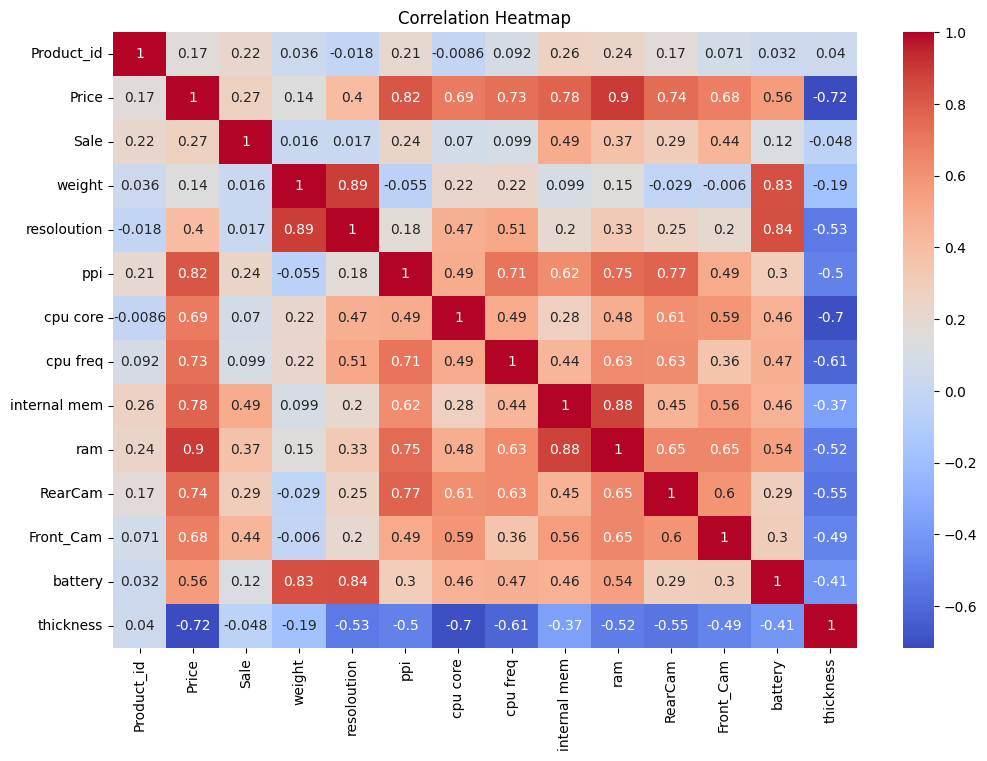

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [11]:
corr=df.corr()["Price"].sort_values(ascending=False)

print(corr)

Price           1.000000
ram             0.896915
ppi             0.817614
internal mem    0.776738
RearCam         0.739538
cpu freq        0.727383
cpu core        0.686811
Front_Cam       0.675286
battery         0.559946
resoloution     0.404010
Sale            0.273263
Product_id      0.165136
weight          0.144555
thickness      -0.716773
Name: Price, dtype: float64


In [12]:
top_features=corr.index[1:5]

print("Top 4 Features")

print(top_features)

Top 4 Features
Index(['ram', 'ppi', 'internal mem', 'RearCam'], dtype='str')


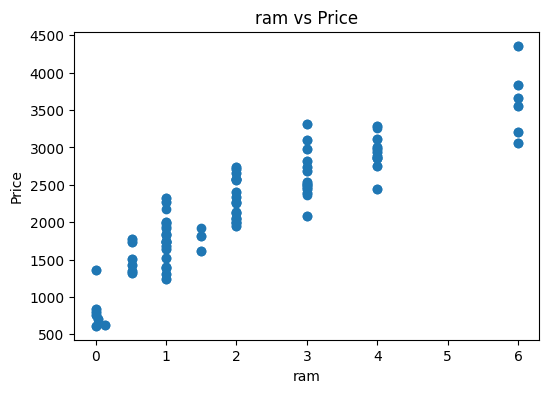

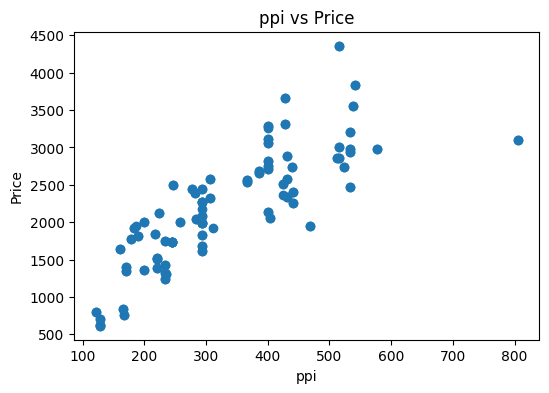

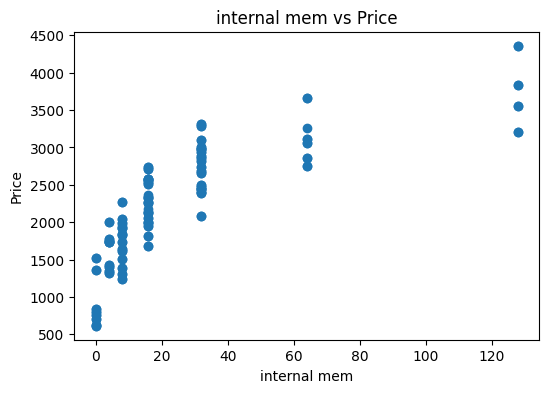

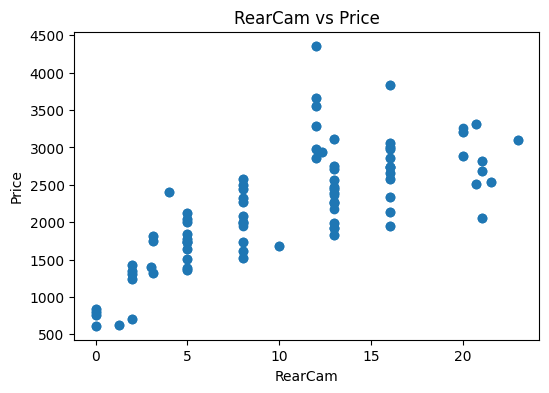

In [13]:
for feature in top_features:

    plt.figure(figsize=(6,4))

    plt.scatter(df[feature],df["Price"])

    plt.xlabel(feature)

    plt.ylabel("Price")

    plt.title(feature+" vs Price")

    plt.show()

In [14]:
X=df[top_features]

y=df["Price"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
model=LinearRegression()

In [17]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[275.47, 1.41, 0.55, 19.96]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['ram','ppi','internal mem','RearCam']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,915.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [18]:
y_pred=model.predict(X_test)

In [19]:
print("Slope (Coefficient):")

for feature,coef in zip(X.columns,model.coef_):
    print(feature,":",coef)

print()

print("Intercept:")

print(model.intercept_)

Slope (Coefficient):
ram : 275.4658234166218
ppi : 1.4097789896057495
internal mem : 0.5495062826705004
RearCam : 19.955669105039185

Intercept:
915.6007300109347


In [20]:
r2=r2_score(y_test,y_pred)

print("R2 Score =",r2)

R2 Score = 0.8527642432104723


In [21]:
mae=mean_absolute_error(y_test,y_pred)

print("MAE =",mae)

MAE = 246.32598849300595


In [22]:
mse=mean_squared_error(y_test,y_pred)

print("MSE =",mse)

MSE = 83466.33539234822


In [23]:
result=pd.DataFrame({

    "Actual Price":y_test,

    "Predicted Price":y_pred

})

result.head(10)

,Actual Price,Predicted Price
105,833,1151.827769
108,1676,1813.890368
142,2508,2761.618943
55,1777,1409.556262
94,1511,1472.374784
29,1950,1618.736628
101,833,1151.827769
51,1347,1338.411023
100,2343,2403.639707
143,2508,2761.618943


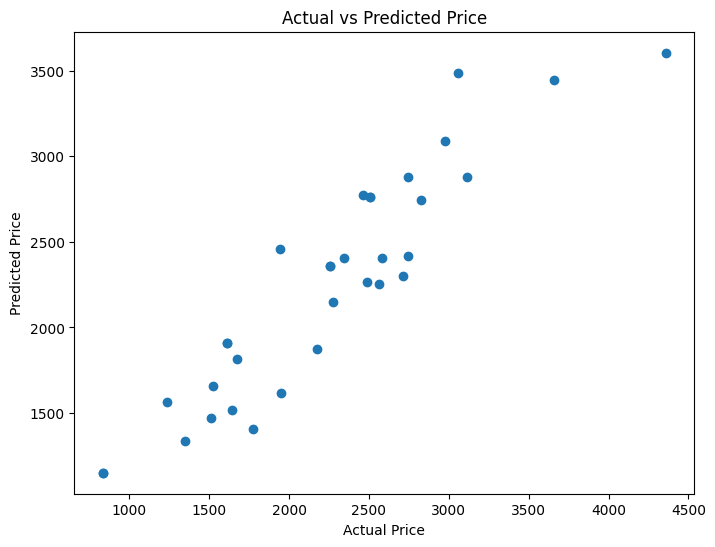

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [25]:
print("Model Evaluation")

print()

print("R2 Score :",r2)

print("MAE :",mae)

print("MSE :",mse)

Model Evaluation

R2 Score : 0.8527642432104723
MAE : 246.32598849300595
MSE : 83466.33539234822
